# Final Retraining Pipeline

This notebook trains the **best configuration found by each candidate algorithm**
(GA, SADE, PSO, GWO) for the categorical 7-HP search space (Study 1), using a
full training budget. Each configuration is trained with **3 different
initialization seeds** to estimate the variance of the retraining.

**Protocol**
- 4 algorithms x 3 seeds = 12 retrainings
- 30 epochs, EarlyStopping(patience=5) on `val_accuracy`, restore best weights
- train = MNIST train (60k), val = MNIST test (10k)
  *(Note: `val_accuracy` reported here equals MNIST test accuracy. Because the
  test set was also used as validation during HPO, it is technically not
  unseen. Selection bias is mild at this stage because only one config per
  algorithm is evaluated — discussed in the methodology section.)*
- Per-epoch history (`accuracy`, `val_accuracy`, `loss`, `val_loss`) is
  recorded for every retraining.

**Outputs**
- `code/colab/results/retrain/retrain_results.json` — full structured results
- `code/colab/results/retrain/retrain_val_accuracy_per_epoch.{png,pdf}` —
  comparison plot
- `code/colab/results/retrain/retrain_summary.{csv,md}` — summary table


## 1. Imports and dataset

In [1]:
import os, sys, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping

# allow imports from sibling utils/
ROOT = Path.cwd()
if (ROOT / 'utils').exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / 'utils').exists():
    sys.path.insert(0, str(ROOT.parent))

from utils.datasets import getDataset
from utils.models   import buildTemplateCNN

print('TF :', tf.__version__)
print('Keras:', keras.__version__)


TF : 2.21.0
Keras: 3.13.2


In [2]:
data = getDataset('mnist')
print('train:', data['x_train'].shape, '| test:', data['x_test'].shape)


  MNIST loaded:
    Train      :  48000 samples
    Val        :  12000 samples  (val_split=0.2)
    Test       :  10000 samples
    Shape      : (28, 28, 1)
    Classes    : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
train: (48000, 28, 28, 1) | test: (10000, 28, 28, 1)


## 2. Locate the best-of-5 config per algorithm

For each algorithm folder under `code/colab/results/<algo>/`, we scan the JSON
files produced by the HPO runs and pick the one whose `best.val_accuracy` is
highest. The selected configuration is what we will retrain.

In [3]:
RESULTS_ROOT = ROOT / 'colab' / 'results'
if not RESULTS_ROOT.exists():
    RESULTS_ROOT = ROOT.parent / 'code' / 'colab' / 'results'

ALGORITHMS = ['ga', 'sade', 'pso', 'gwo','bo' ]

def find_best_config(algo_dir: Path):
    best = None
    for jp in sorted(algo_dir.glob('*.json')):
        with open(jp, 'r') as f:
            d = json.load(f)
        if best is None or d['best']['val_accuracy'] > best['val_accuracy']:
            best = {
                'algorithm':   d.get('algorithm', algo_dir.name.upper()),
                'tag':         jp.stem,
                'val_accuracy': d['best']['val_accuracy'],
                'fitness':      d['best']['fitness'],
                'config':       d['best']['config'],
            }
    return best

best_configs = {algo.upper(): find_best_config(RESULTS_ROOT / algo / 'mnist')
                for algo in ALGORITHMS}

for algo, info in best_configs.items():
    print(f'--- {algo} ---')
    print(f'  source run : {info["tag"]}')
    print(f'  HPO val_acc: {info["val_accuracy"]:.4f}')
    cfg = info['config']
    print(f'  config     : bs={cfg["batch_size"]}, f0={cfg["base_filters"]}, '
          f'blocks={cfg["n_blocks"]}, dense={cfg["dense_units"]}, '
          f'opt={cfg["optimizer"]}, pool={cfg["pooling"]}, k={cfg["kernel_size"]}')


--- GA ---
  source run : GA_20260506_150811
  HPO val_acc: 0.9933
  config     : bs=64, f0=32, blocks=3, dense=128, opt=rmsprop, pool=max, k=3
--- SADE ---
  source run : SADE_20260505_223222
  HPO val_acc: 0.9924
  config     : bs=32, f0=32, blocks=3, dense=512, opt=rmsprop, pool=max, k=3
--- PSO ---
  source run : AIW_PSO_20260506_042309
  HPO val_acc: 0.9901
  config     : bs=64, f0=32, blocks=3, dense=256, opt=adamw, pool=max, k=5
--- GWO ---
  source run : GWO_20260506_151829
  HPO val_acc: 0.9902
  config     : bs=32, f0=32, blocks=3, dense=128, opt=adamw, pool=max, k=3
--- BO ---
  source run : BO_20260521_100723
  HPO val_acc: 0.9917
  config     : bs=32, f0=32, blocks=3, dense=512, opt=adamw, pool=average, k=3


## 3. Retrain each best config with 3 seeds

In [4]:
SEEDS         = [0, 1, 2]
EPOCHS        = 30
PATIENCE      = 5
INPUT_SHAPE   = data['x_train'].shape[1:]
NUM_CLASSES   = data['num_classes']

OUT_DIR = RESULTS_ROOT / 'retrain' / 'mnist'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def set_global_seed(seed: int):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        keras.utils.set_random_seed(seed)
    except AttributeError:
        pass

def train_one(config: dict, seed: int):
    set_global_seed(seed)
    model = buildTemplateCNN(config, INPUT_SHAPE, NUM_CLASSES)
    es = EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                       restore_best_weights=True, verbose=0)
    t0 = time.time()
    history = model.fit(
        data['x_train'], data['y_train'],
        validation_data=(data['x_val'], data['y_val']),
        epochs=EPOCHS,
        shuffle=True,
        batch_size=config['batch_size'],
        callbacks=[es],
        verbose=0,
    )
    elapsed = time.time() - t0
    h = history.history
    val_acc = np.array(h['val_accuracy'], dtype=float)
    best_epoch = int(np.argmax(val_acc))

    # Evaluate on held-out test set (never seen during training/HPO)
    test_loss, test_acc = model.evaluate(data['x_test'], data['y_test'], verbose=0)

    return {
        'seed':              seed,
        'n_epochs_trained':  len(val_acc),
        'best_epoch':        best_epoch + 1,
        'best_val_accuracy': float(val_acc[best_epoch]),
        'final_val_accuracy':float(val_acc[-1]),
        'test_accuracy':     float(test_acc),
        'test_loss':         float(test_loss),
        'history':           {
            'accuracy':     [float(v) for v in h['accuracy']],
            'val_accuracy': [float(v) for v in h['val_accuracy']],
            'loss':         [float(v) for v in h['loss']],
            'val_loss':     [float(v) for v in h['val_loss']],
        },
        'n_params':          int(model.count_params()),
        'elapsed_s':         float(elapsed),
    }


In [5]:
retrain_results = {}

for algo, info in best_configs.items():
    print(f'\n========== Retraining {algo} ==========')
    print(f'  source : {info["tag"]}  (HPO val_acc = {info["val_accuracy"]:.4f})')
    runs = []
    for seed in SEEDS:
        print(f'  seed {seed} ...', end=' ', flush=True)
        r = train_one(info['config'], seed)
        runs.append(r)
        print(f'best_val_acc={r["best_val_accuracy"]:.4f}  '
              f'epochs={r["n_epochs_trained"]}  '
              f'time={r["elapsed_s"]:.0f}s')
    retrain_results[algo] = {
        'source_run':      info['tag'],
        'hpo_val_accuracy': info['val_accuracy'],
        'config':           info['config'],
        'runs':             runs,
    }

# Save full results to JSON
out_json = OUT_DIR / 'retrain_results_bo.json'
with open(out_json, 'w') as f:
    json.dump(retrain_results, f, indent=2)
print(f'\nSaved: {out_json}')



========== Retraining GA ==========
  source : GA_20260506_150811  (HPO val_acc = 0.9933)
  seed 0 ... WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
best_val_acc=0.9942  epochs=19  time=336s
  seed 1 ... best_val_acc=0.9952  epochs=30  time=533s
  seed 2 ... best_val_acc=0.9912  epochs=9  time=167s

========== Retraining SADE ==========
  source : SADE_20260505_223222  (HPO val_acc = 0.9924)
  seed 0 ... best_val_acc=0.9950  epochs=24  time=506s
  seed 1 ... best_val_acc=0.9923  epochs=15  time=314s
  seed 2 ... best_val_acc=0.9921  epochs=10  time=227s

========== Retraining PSO ==========
  source : AIW_PSO_20260506_042309  (HPO val_acc = 0.9901)
  seed 0 ... best_val_acc=0.9930  epochs=15  time=449s
  seed 1 ... best_val_acc=0.9895  epochs=10  time=317s
  seed 2 ... best_val_acc=0.9934  epochs=18  time=643s

========== Ret

## 4. Plot: validation accuracy per epoch, one line per algorithm

Each curve is the mean over the 3 seeds and the shaded band is +/-1 std.
Where a seed stopped earlier than the others (early stopping), its history is
padded with `NaN` so that mean/std are computed only over the seeds that
actually reached that epoch.

c:\Users\ruben\repos\tese-mestrado\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ruben\AppData\Local\Temp\ipykernel_18628\1010325000.py:22: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)


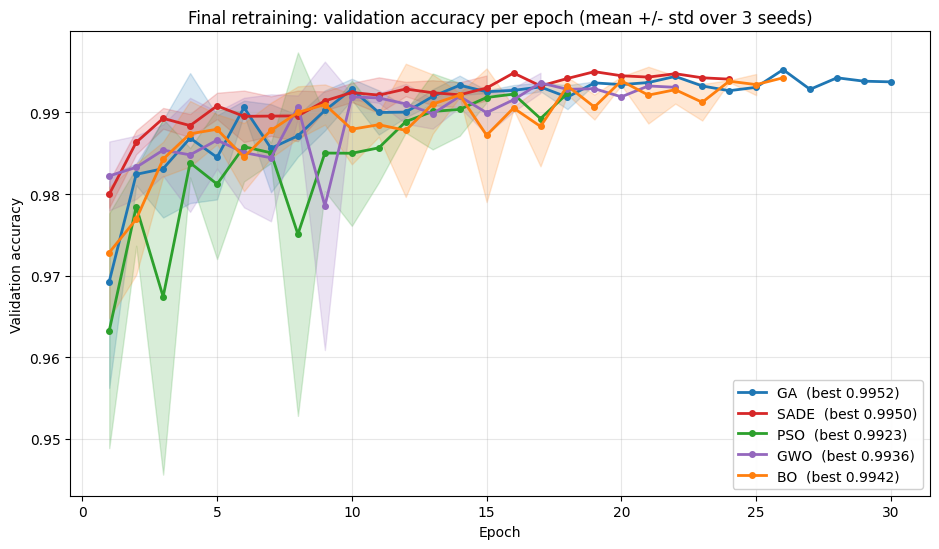

Saved: c:\Users\ruben\repos\tese-mestrado\code\colab\results\retrain\mnist\retrain_val_accuracy_per_epoch.png
Saved: c:\Users\ruben\repos\tese-mestrado\code\colab\results\retrain\mnist\retrain_val_accuracy_per_epoch.pdf


In [6]:
COLORS = {'GA': '#1f77b4', 'SADE': '#d62728', 'PSO': '#2ca02c', 'GWO': '#9467bd' , 'BO': '#ff7f0e'}

def pad_to(arr, n):
    out = np.full(n, np.nan, dtype=float)
    out[:len(arr)] = arr
    return out

max_len = max(
    r['n_epochs_trained']
    for algo in retrain_results.values()
    for r in algo['runs']
)
epochs_axis = np.arange(1, max_len + 1)

fig, ax = plt.subplots(figsize=(9.5, 5.6))

for algo, payload in retrain_results.items():
    M = np.vstack([
        pad_to(np.array(r['history']['val_accuracy']), max_len)
        for r in payload['runs']
    ])
    mean = np.nanmean(M, axis=0)
    std  = np.nanstd(M, axis=0, ddof=1) if M.shape[0] > 1 else np.zeros_like(mean)
    c = COLORS.get(algo, None)
    ax.fill_between(epochs_axis, mean - std, mean + std, color=c, alpha=0.18)
    ax.plot(epochs_axis, mean, color=c, linewidth=2, marker='o', markersize=4,
            label=f'{algo}  (best {np.nanmax(mean):.4f})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy')
ax.set_title(f'Final retraining: validation accuracy per epoch '
             f'(mean +/- std over {len(SEEDS)} seeds)')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=10, framealpha=0.92)
plt.tight_layout()

out_png = OUT_DIR / 'retrain_val_accuracy_per_epoch.png'
out_pdf = OUT_DIR / 'retrain_val_accuracy_per_epoch.pdf'
plt.savefig(out_png, dpi=160, bbox_inches='tight')
plt.savefig(out_pdf, bbox_inches='tight')
plt.show()
print('Saved:', out_png)
print('Saved:', out_pdf)


## 5. (Optional) Validation loss per epoch

Useful to diagnose late overfit. Same format as the accuracy plot.

c:\Users\ruben\repos\tese-mestrado\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ruben\AppData\Local\Temp\ipykernel_18628\3539919907.py:8: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=0)


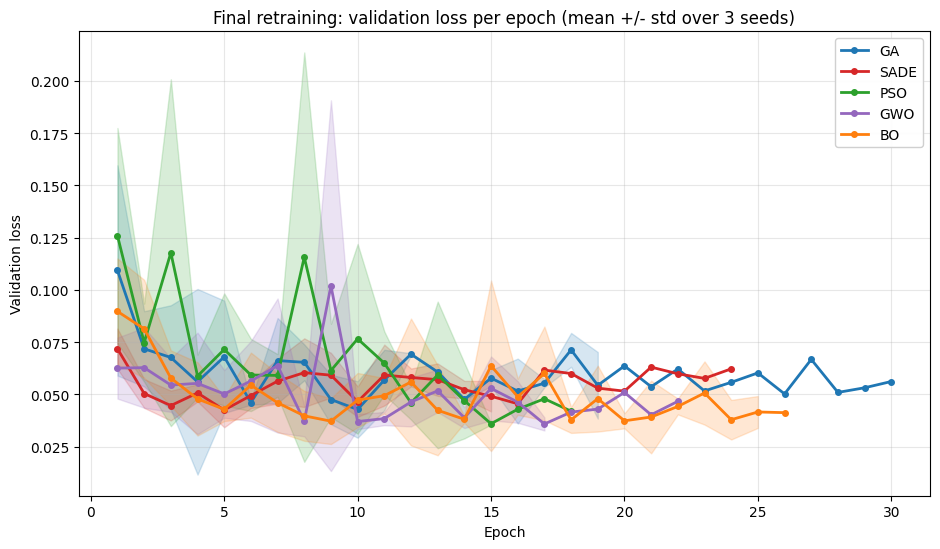

Saved: c:\Users\ruben\repos\tese-mestrado\code\colab\results\retrain\mnist\retrain_val_loss_per_epoch.png
Saved: c:\Users\ruben\repos\tese-mestrado\code\colab\results\retrain\mnist\retrain_val_loss_per_epoch.pdf


In [7]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))

for algo, payload in retrain_results.items():
    M = np.vstack([
        pad_to(np.array(r['history']['val_loss']), max_len)
        for r in payload['runs']
    ])
    mean = np.nanmean(M, axis=0)
    std  = np.nanstd(M, axis=0, ddof=1) if M.shape[0] > 1 else np.zeros_like(mean)
    c = COLORS.get(algo, None)
    ax.fill_between(epochs_axis, mean - std, mean + std, color=c, alpha=0.18)
    ax.plot(epochs_axis, mean, color=c, linewidth=2, marker='o', markersize=4,
            label=algo)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation loss')
ax.set_title(f'Final retraining: validation loss per epoch '
             f'(mean +/- std over {len(SEEDS)} seeds)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10, framealpha=0.92)
plt.tight_layout()

out_png = OUT_DIR / 'retrain_val_loss_per_epoch.png'
out_pdf = OUT_DIR / 'retrain_val_loss_per_epoch.pdf'
plt.savefig(out_png, dpi=160, bbox_inches='tight')
plt.savefig(out_pdf, bbox_inches='tight')
plt.show()
print('Saved:', out_png)
print('Saved:', out_pdf)


## 6. Summary table

One row per algorithm with mean +/- std of best val accuracy across the 3
seeds, plus the best epoch, total parameters and average training time.

In [8]:
rows = []
for algo, payload in retrain_results.items():
    val_accs  = np.array([r['best_val_accuracy'] for r in payload['runs']])
    test_accs = np.array([r['test_accuracy']      for r in payload['runs']])
    epochs    = np.array([r['best_epoch']          for r in payload['runs']])
    times     = np.array([r['elapsed_s']           for r in payload['runs']])
    nparam    = payload['runs'][0]['n_params']
    rows.append({
        'Algorithm':                 algo,
        'HPO val_acc':               f"{payload['hpo_val_accuracy']:.4f}",
        'Val acc (mean+/-std)':      f"{val_accs.mean():.4f} +/- {val_accs.std(ddof=1):.4f}",
        'Test acc (mean+/-std)':     f"{test_accs.mean():.4f} +/- {test_accs.std(ddof=1):.4f}",
        'Best epoch (mean+/-std)':   f"{epochs.mean():.1f} +/- {epochs.std(ddof=1):.1f}",
        'Train time s (mean+/-std)': f"{times.mean():.1f} +/- {times.std(ddof=1):.1f}",
        '# Params':                  f"{nparam:,}",
        'Source run':                payload['source_run'],
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

df.to_csv(OUT_DIR / 'retrain_summary.csv', index=False)

md_lines = ['| ' + ' | '.join(df.columns) + ' |',
            '| ' + ' | '.join('---' for _ in df.columns) + ' |']
for _, r in df.iterrows():
    md_lines.append('| ' + ' | '.join(str(r[c]) for c in df.columns) + ' |')
(OUT_DIR / 'retrain_summary.md').write_text('\n'.join(md_lines), encoding='utf-8')

print(f"\nSaved: {OUT_DIR / 'retrain_summary.csv'}")
print(f"Saved: {OUT_DIR / 'retrain_summary.md'}")


Algorithm HPO val_acc Val acc (mean+/-std) Test acc (mean+/-std) Best epoch (mean+/-std) Train time s (mean+/-std)  # Params              Source run
       GA      0.9933    0.9936 +/- 0.0021     0.9937 +/- 0.0018           14.7 +/- 11.0           345.1 +/- 183.4   437,098      GA_20260506_150811
     SADE      0.9924    0.9931 +/- 0.0016     0.9938 +/- 0.0009            11.3 +/- 7.1           349.1 +/- 143.0   883,690    SADE_20260505_223222
      PSO      0.9901    0.9920 +/- 0.0022     0.9926 +/- 0.0011             9.3 +/- 4.0           469.5 +/- 164.0 1,094,378 AIW_PSO_20260506_042309
      GWO      0.9902    0.9930 +/- 0.0014     0.9937 +/- 0.0009            13.3 +/- 3.2            458.3 +/- 75.6   437,098     GWO_20260506_151829
       BO      0.9917    0.9941 +/- 0.0006     0.9942 +/- 0.0002            16.7 +/- 6.7           521.1 +/- 153.6   883,690      BO_20260521_100723

Saved: c:\Users\ruben\repos\tese-mestrado\code\colab\results\retrain\mnist\retrain_summary.csv
Saved: c:\

## 7. Configurations used (for reproducibility)

A second table listing the full configuration retrained for each algorithm.

In [ ]:
cfg_rows = []
for algo, payload in retrain_results.items():
    c = payload['config']
    cfg_rows.append({
        'Algorithm':   algo,
        'batch_size':  c['batch_size'],
        'base_filters': c['base_filters'],
        'n_blocks':    c['n_blocks'],
        'dense_units': c['dense_units'],
        'optimizer':   c['optimizer'],
        'pooling':     c['pooling'],
        'kernel_size': c['kernel_size'],
        'learning_rate': c.get('learning_rate'),
        'dropout_rate':  c.get('dropout_rate'),
        'activation':    c.get('activation'),
    })

df_cfg = pd.DataFrame(cfg_rows)
print(df_cfg.to_string(index=False))

df_cfg.to_csv(OUT_DIR / 'retrain_configs.csv', index=False)
print(f"\nSaved: {OUT_DIR / 'retrain_configs.csv'}")


Algorithm  batch_size  base_filters  n_blocks  dense_units optimizer pooling  kernel_size  learning_rate  dropout_rate activation
       GA          64            32         3          128   rmsprop     max            3          0.001           0.5       relu
     SADE          32            32         3          512   rmsprop     max            3          0.001           0.5       relu
      PSO          64            32         3          256     adamw     max            5          0.001           0.5       relu
      GWO          32            32         3          128     adamw     max            3          0.001           0.5       relu
       BO          32            32         3          512     adamw average            3          0.001           0.5       relu

Saved: c:\Users\ruben\repos\tese-mestrado\code\colab\results\retrain\mnist\retrain_configs.csv


: 